In [ ]:
# import necessary libraries
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [ ]:
# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Plotting style
sns.set_theme(style="whitegrid")

In [ ]:
# Download the dataset from Kaggle and save it to the current directory
path = kagglehub.dataset_download(
    "datascikhan/e-commerce-sales-and-customer-analytics",
    path="ecommerce_sales_customer_analytics_150k.csv",
    output_dir="."
)

print("Path to dataset file:", path)

Using Colab cache for faster access to the 'e-commerce-sales-and-customer-analytics' dataset.
Path to dataset file: /kaggle/input/e-commerce-sales-and-customer-analytics/ecommerce_sales_customer_analytics_150k.csv


In [ ]:
df = pd.read_csv(path)

In [ ]:
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [ ]:
# DATA CLEANING

# Keep original data unchanged
df_raw = df.copy()

# Create working copy for cleaning
df_clean = df.copy()

print("Raw dataset shape:", df_raw.shape)
print("Working dataset shape:", df_clean.shape)

Raw dataset shape: (138116, 46)
Working dataset shape: (138116, 46)


In [ ]:
# DUPLICATE CHECK

print("Complete duplicate rows:", df_clean.duplicated().sum())

print("Duplicate order IDs:", df_clean["order_id"].duplicated().sum())

print("Unique order IDs:", df_clean["order_id"].nunique())

print("Total rows:", len(df_clean))

Complete duplicate rows: 0
Duplicate order IDs: 0
Unique order IDs: 138116
Total rows: 138116


In [ ]:
print("\nColumn names:")
print(df_clean.columns.tolist())


Column names:
['order_id', 'order_date', 'order_time', 'order_status', 'sales_channel', 'customer_id', 'customer_name', 'customer_age', 'gender', 'customer_segment', 'customer_type', 'customer_city', 'customer_state', 'customer_country', 'region', 'customer_postal_code', 'payment_method', 'payment_status', 'currency', 'shipping_method', 'warehouse', 'delivery_days', 'estimated_delivery_days', 'delivery_status', 'return_status', 'return_reason', 'customer_rating', 'review_sentiment', 'customer_review', 'marketing_channel', 'campaign_name', 'coupon_code', 'loyalty_points_earned', 'loyalty_points_redeemed', 'quantity', 'gross_sales', 'discount_amount', 'tax_amount', 'shipping_cost', 'net_sales', 'product_cost', 'profit', 'profit_margin_percentage', 'customer_lifetime_value', 'is_repeat_customer', 'customer_order_count']


In [ ]:
print("\nData types:")
print(df_clean.dtypes)


Data types:
order_id                     object
order_date                   object
order_time                   object
order_status                 object
sales_channel                object
customer_id                  object
customer_name                object
customer_age                  int64
gender                       object
customer_segment             object
customer_type                object
customer_city                object
customer_state               object
customer_country             object
region                       object
customer_postal_code          int64
payment_method               object
payment_status               object
currency                     object
shipping_method              object
warehouse                    object
delivery_days               float64
estimated_delivery_days     float64
delivery_status              object
return_status                object
return_reason                object
customer_rating             float64
review_sentimen

In [ ]:
print("\nDataFrame info:")
df_clean.info()


DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138116 entries, 0 to 138115
Data columns (total 46 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  138116 non-null  object 
 1   order_date                138116 non-null  object 
 2   order_time                138116 non-null  object 
 3   order_status              138116 non-null  object 
 4   sales_channel             138116 non-null  object 
 5   customer_id               138116 non-null  object 
 6   customer_name             138116 non-null  object 
 7   customer_age              138116 non-null  int64  
 8   gender                    138116 non-null  object 
 9   customer_segment          138116 non-null  object 
 10  customer_type             138116 non-null  object 
 11  customer_city             138116 non-null  object 
 12  customer_state            138116 non-null  object 
 13  customer_country          1

In [ ]:
print("\nFirst 5 rows of the DataFrame:")
df_clean.head(5)


First 5 rows of the DataFrame:


,order_id,order_date,order_time,order_status,sales_channel,customer_id,customer_name,customer_age,gender,customer_segment,customer_type,customer_city,customer_state,customer_country,region,customer_postal_code,payment_method,payment_status,currency,shipping_method,warehouse,delivery_days,estimated_delivery_days,delivery_status,return_status,return_reason,customer_rating,review_sentiment,customer_review,marketing_channel,campaign_name,coupon_code,loyalty_points_earned,loyalty_points_redeemed,quantity,gross_sales,discount_amount,tax_amount,shipping_cost,net_sales,product_cost,profit,profit_margin_percentage,customer_lifetime_value,is_repeat_customer,customer_order_count
0,ORD-301242,2023-11-06,16:37:47,Completed,Mobile App,CUST-003102,Jasmine Ryan,55,Male,Consumer,Loyal,Lake Williamberg,Texas,USA,South,86040,Digital Wallet,Paid,USD,Standard,WH-003,3.00,3.00,On Time,NaN,NaN,3.50,Positive,Satisfied with the purchase.,Direct,Default_Campaign,NaN,94,44,5,"1,350.19",477.89,61.07,12.03,945.40,588.33,345.04,36.50,"12,459.68",True,11
1,ORD-773460,2025-12-24,01:22:36,Completed,Website,CUST-003124,Scott Chase,26,Male,Premium,Loyal,Kristyport,Baden-Württemberg,Germany,South,62538,Debit Card,Pending,EUR,Economy,WH-005,10.00,10.00,On Time,NaN,NaN,3.60,Positive,Good value for money.,Direct,Default_Campaign,NaN,201,171,8,"3,144.64","1,456.06",320.83,9.00,"2,018.41","2,031.88",-22.47,-1.11,"13,032.48",True,11
2,ORD-449374,2021-07-05,14:24:21,Completed,Mobile App,CUST-012496,Marc Wheeler,69,Female,Premium,Loyal,Singletonhaven,New York,USA,East,19993,Cash on Delivery,Paid,USD,Express,WH-015,3.00,3.00,On Time,NaN,NaN,4.30,Positive,Good product. Works as expected.,YouTube,NaN,NaN,46,16,5,522.81,97.30,29.79,13.05,468.35,257.73,197.57,42.18,"6,159.44",True,6
3,ORD-567636,2023-01-21,07:20:26,Completed,Social Media,CUST-023928,Jennifer Smith,65,Male,Consumer,Loyal,Wigginsstad,North Carolina,USA,South,66329,Debit Card,Paid,USD,Express,WH-010,2.00,2.00,On Time,NaN,NaN,3.50,Positive,Satisfied with the purchase.,Email Marketing,NaN,NaN,54,10,2,544.62,53.34,34.39,20.85,546.52,277.84,247.83,45.35,"5,638.30",True,7
4,ORD-820028,2022-05-13,09:46:21,Completed,Social Media,CUST-012730,Jessica Wang,34,Female,Consumer,Loyal,New Michaelton,Gujarat,India,West,77306,Digital Wallet,Paid,INR,Standard,WH-013,6.00,5.00,Delayed,NaN,NaN,3.00,Neutral,Mixed feelings about this purchase.,Direct,NaN,NaN,278,147,6,"2,474.52",133.63,421.35,23.03,"2,785.27","1,231.88","1,530.36",54.94,"13,240.10",True,8


In [ ]:
print("\nFeature summary:")
feature_summary = pd.DataFrame({
    "Column": df_clean.columns,
    "Missing Values": df_clean.isnull().sum().values,
    "Missing %": (df_clean.isnull().mean() * 100).round(2).values,
    "Unique Values": df_clean.nunique().values
})

feature_summary


Feature summary:


,Column,Missing Values,Missing %,Unique Values
0,order_id,0,0.00,138116
1,order_date,0,0.00,1826
2,order_time,0,0.00,68991
3,order_status,0,0.00,4
4,sales_channel,0,0.00,4
5,customer_id,0,0.00,24911
6,customer_name,0,0.00,21564
7,customer_age,0,0.00,57
8,gender,0,0.00,3
9,customer_segment,0,0.00,4


In [ ]:
# MISSING VALUE ANALYSIS

missing = pd.DataFrame({
    "Missing Count": df_clean.isnull().sum(),
    "Missing Percentage": (df_clean.isnull().mean() * 100).round(2)
})

missing = missing[missing["Missing Count"] > 0]

print("Columns containing missing values:")
display(missing.sort_values("Missing Count", ascending=False))

Columns containing missing values:


,Missing Count,Missing Percentage
return_status,128654,93.15
return_reason,128654,93.15
coupon_code,110502,80.01
campaign_name,83233,60.26
delivery_days,24557,17.78
customer_rating,24557,17.78
estimated_delivery_days,24557,17.78
customer_review,24557,17.78
review_sentiment,24557,17.78


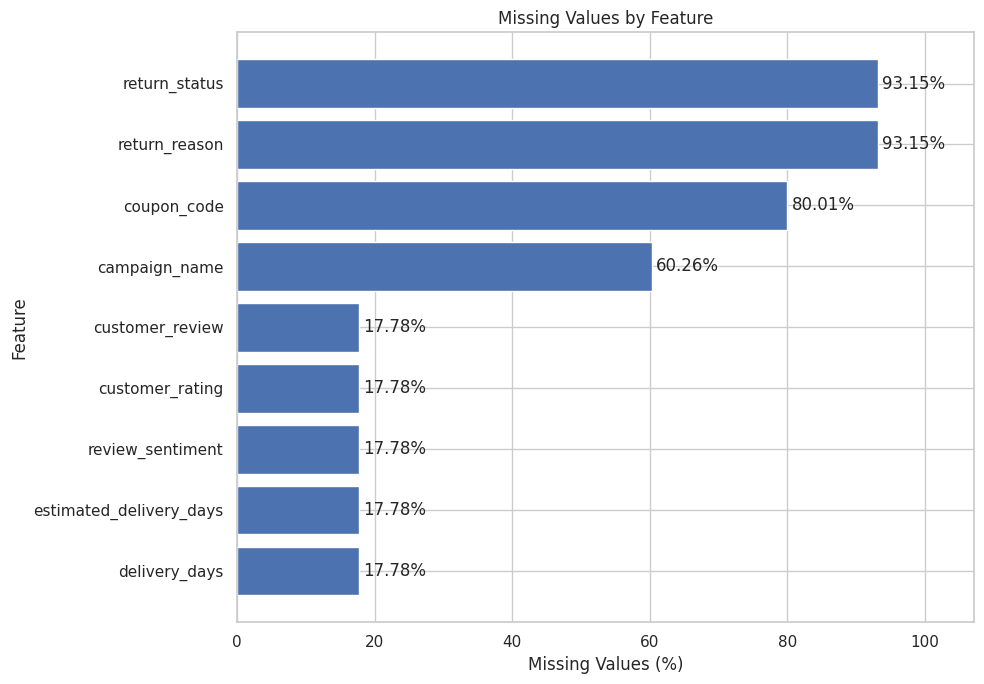

In [ ]:
# MISSING VALUE VISUALIZATION

missing_sorted = missing.sort_values(
    "Missing Percentage",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    missing_sorted.index,
    missing_sorted["Missing Percentage"]
)

ax.bar_label(bars, fmt="%.2f%%", padding=3)

ax.set_xlabel("Missing Values (%)")
ax.set_ylabel("Feature")
ax.set_title("Missing Values by Feature")

ax.set_xlim(0, missing_sorted["Missing Percentage"].max() * 1.15)

plt.tight_layout()
plt.show()

In [ ]:
# HANDLE STRUCTURAL MISSING VALUES

# Return-related fields
df_clean["return_status"] = df_clean["return_status"].fillna(
    "Not Returned"
)

df_clean["return_reason"] = df_clean["return_reason"].fillna(
    "Not Returned"
)

# Marketing fields
df_clean["campaign_name"] = df_clean["campaign_name"].fillna(
    "No Campaign"
)

df_clean["coupon_code"] = df_clean["coupon_code"].fillna(
    "No Coupon"
)

# Review fields
df_clean["review_sentiment"] = df_clean["review_sentiment"].fillna(
    "No Review"
)

df_clean["customer_review"] = df_clean["customer_review"].fillna(
    "No Review"
)

print(
    df_clean[["return_status", "return_reason", "campaign_name",
            "coupon_code", "review_sentiment", "customer_review"
        ]].isna().sum()
)

return_status       0
return_reason       0
campaign_name       0
coupon_code         0
review_sentiment    0
customer_review     0
dtype: int64


In [ ]:
# ============================================================
# INVESTIGATE MISSING DELIVERY INFORMATION
# ============================================================

delivery_missing = df_clean[df_clean["delivery_days"].isna()]

print("Rows missing delivery days:", len(delivery_missing))

print("\nDelivery status for rows with missing delivery days:")
print(delivery_missing["delivery_status"].value_counts(dropna=False))

Rows missing delivery days: 24557

Delivery status for rows with missing delivery days:
delivery_status
Cancelled    24557
Name: count, dtype: int64


In [ ]:
# Keep delivery_days and estimated_delivery_days as NaN
# because cancelled orders never had a delivery.

print(
    df_clean.loc[df_clean["delivery_days"].isna(), "delivery_status"]
    .value_counts(dropna=False)
)

delivery_status
Cancelled    24557
Name: count, dtype: int64


In [ ]:
# ============================================================
# CUSTOMER RATING / REVIEW ANALYSIS
# ============================================================

rating_missing = df_clean["customer_rating"].isna()

print("Missing ratings:", rating_missing.sum())

print("\nReview status among missing ratings:")
print(
    df_clean.loc[
        rating_missing,
        "review_sentiment"
    ].value_counts(dropna=False)
)

Missing ratings: 24557

Review status among missing ratings:
review_sentiment
No Review    24557
Name: count, dtype: int64


In [ ]:
# Keep customer_rating as NaN
# because "no rating" is different from a rating of 0.

print(
    df_clean.loc[df_clean["customer_rating"].isna(), "review_sentiment"]
    .value_counts(dropna=False)
)

review_sentiment
No Review    24557
Name: count, dtype: int64


In [ ]:
# DATE AND TIME CLEANING

df_clean["order_datetime"] = pd.to_datetime(
    df_clean["order_date"].astype(str)
    + " "
    + df_clean["order_time"].astype(str),
    errors="coerce"
)

print(
    "Unparsed order_datetime values:",
    df_clean["order_datetime"].isna().sum()
)

Unparsed order_datetime values: 0


In [ ]:
# TIME-BASED FEATURES

df_clean["order_date"] = df_clean["order_datetime"].dt.normalize()

df_clean["order_year"] = (
    df_clean["order_datetime"].dt.year
)

df_clean["order_month"] = (
    df_clean["order_datetime"].dt.month
)

df_clean["order_month_name"] = (
    df_clean["order_datetime"].dt.month_name()
)

df_clean["order_day"] = (
    df_clean["order_datetime"].dt.day
)

df_clean["order_quarter"] = (
    df_clean["order_datetime"].dt.quarter
)

df_clean["order_hour"] = (
    df_clean["order_datetime"].dt.hour
)

df_clean["order_weekday"] = (
    df_clean["order_datetime"].dt.day_name()
)

df_clean["is_weekend"] = (
    df_clean["order_datetime"].dt.dayofweek >= 5
)

In [ ]:
df_clean[
    ["order_datetime", "order_year", "order_month", "order_day",
     "order_month_name", "order_quarter", "order_hour", "order_weekday", "is_weekend"]
].head()

,order_datetime,order_year,order_month,order_day,order_month_name,order_quarter,order_hour,order_weekday,is_weekend
0,2023-11-06 16:37:47,2023,11,6,November,4,16,Monday,False
1,2025-12-24 01:22:36,2025,12,24,December,4,1,Wednesday,False
2,2021-07-05 14:24:21,2021,7,5,July,3,14,Monday,False
3,2023-01-21 07:20:26,2023,1,21,January,1,7,Saturday,True
4,2022-05-13 09:46:21,2022,5,13,May,2,9,Friday,False


In [ ]:
# CHECK DATE RANGE FOR LATER ANALYSIS

print("Minimum order date:",
      df_clean["order_datetime"].min())

print("Maximum order date:",
      df_clean["order_datetime"].max())

Minimum order date: 2021-01-01 00:01:30
Maximum order date: 2025-12-31 23:58:53


In [ ]:
# CHECK CUSTOMER AGE IF REASONABLE

print("Minimum age:",
      df_clean["customer_age"].min())

print("Maximum age:",
      df_clean["customer_age"].max())

Minimum age: 18
Maximum age: 74


Why the cleaning decisions are appropriate
The missing values are mostly structural rather than random errors. Cancelled orders do not have delivery times, ratings, or reviews, so those values remain missing. Return, campaign, coupon, and review text fields were filled with labels such as Not Returned, No Campaign, No Coupon, and No Review. These labels preserve the meaning of the missingness instead of incorrectly replacing it with zero or an average.
The separate order_datetime column combines the date and time into one true datetime field. From it, year, month, quarter, hour, weekday, and weekend indicators are created so that orders can be analyzed by time.

In [ ]:
# done with cleaning the dataset
# part 1 checking
summary = pd.DataFrame({
    'Metric': ['Rows', 'Original columns', 'Customers', 'Date range start', 'Date range end', 'Duplicate rows'],
    'Value': [
    len(df_clean),
    len(df_raw.columns),
    df_clean["customer_id"].nunique(),
    df_clean["order_datetime"].min(),
    df_clean["order_datetime"].max(),
    df_clean.duplicated().sum()
]
})
summary

,Metric,Value
0,Rows,138116
1,Original columns,46
2,Customers,24911
3,Date range start,2021-01-01 00:01:30
4,Date range end,2025-12-31 23:58:53
5,Duplicate rows,0


In [ ]:
# CREATE REUSABLE MONTHLY AND BUSINESS SUMMARY TABLES
# Completed orders are used for sales/profit analysis because cancelled
# orders do not represent completed revenue.
completed = df_clean[df_clean["order_status"] == "Completed"].copy()
completed["order_month_period"] = completed["order_datetime"].dt.to_period("M")

monthly_summary = (
    completed.groupby("order_month_period", as_index=False)
    .agg(
        Orders=("order_id", "nunique"),
        Net_Sales=("net_sales", "sum"),
        Profit=("profit", "sum"),
        Average_Order_Value=("net_sales", "mean"),
    )
    .sort_values("order_month_period")
)
monthly_summary["order_month"] = monthly_summary["order_month_period"].astype(str)

channel_summary = (
    completed.groupby("sales_channel", as_index=False)
    .agg(
        Orders=("order_id", "nunique"),
        Net_Sales=("net_sales", "sum"),
        Profit=("profit", "sum"),
        Average_Rating=("customer_rating", "mean"),
    )
    .sort_values("Net_Sales", ascending=False)
)
channel_summary["Profit_Margin"] = (
    channel_summary["Profit"]
    .div(channel_summary["Net_Sales"].replace(0, np.nan))
    .mul(100)
)

segment_summary = (
    completed.groupby("customer_segment", as_index=False)
    .agg(
        Orders=("order_id", "nunique"),
        Net_Sales=("net_sales", "sum"),
        Profit=("profit", "sum"),
        Average_Order_Value=("net_sales", "mean"),
        Repeat_Customer_Rate=("is_repeat_customer", "mean"),
    )
    .sort_values("Net_Sales", ascending=False)
)
segment_summary["Repeat_Customer_Rate"] *= 100
segment_summary["Profit_Margin"] = (
    segment_summary["Profit"]
    .div(segment_summary["Net_Sales"].replace(0, np.nan))
    .mul(100)
)

display(monthly_summary.head())
display(channel_summary)
display(segment_summary)

,order_month_period,Orders,Net_Sales,Profit,Average_Order_Value,order_month
0,2021-01,1592,"1,997,016.51","934,359.07","1,254.41",2021-01
1,2021-02,1285,"1,531,619.97","710,644.11","1,191.92",2021-02
2,2021-03,1820,"2,301,527.56","1,067,744.73","1,264.58",2021-03
3,2021-04,1609,"2,018,898.21","947,983.07","1,254.75",2021-04
4,2021-05,1709,"2,001,701.65","938,230.04","1,171.27",2021-05


,sales_channel,Orders,Net_Sales,Profit,Average_Rating,Profit_Margin
1,Mobile App,45505,"57,617,393.09","23,877,394.95",3.68,41.44
3,Website,39606,"50,345,188.15","20,887,959.08",3.68,41.49
0,Marketplace,16987,"21,775,779.70","8,983,667.03",3.67,41.26
2,Social Media,11461,"14,457,477.56","6,009,447.97",3.68,41.57


,customer_segment,Orders,Net_Sales,Profit,Average_Order_Value,Repeat_Customer_Rate,Profit_Margin
1,Consumer,62211,"79,281,384.84","33,863,806.21","1,274.39",99.75,42.71
2,Premium,28544,"35,844,446.89","14,019,935.57","1,255.76",99.76,39.11
3,VIP,11506,"14,618,819.57","5,741,654.71","1,270.54",99.78,39.28
0,Business,11298,"14,451,187.20","6,133,072.54","1,279.09",99.74,42.44


1. a cancelled order may have a sales amount in the dataset, but the company
did not successfully complete that sale.
2. a month column is created to compare orders month by month instead of comparing every individual date and time.
3. monthly summary is created to




In [ ]:
# FIGURE SETTINGS
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates

FIG_DIR = Path("eda_figures")
FIG_DIR.mkdir(exist_ok=True)

# Consistent colors and typography make the figures look like one study.
COLORS = {
    "primary": "#1f4e79",
    "secondary": "#4f81bd",
    "accent": "#c0504d",
    "positive": "#2f7d32",
    "neutral": "#7f8c8d",
    "highlight": "#d98c00",
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.frameon": False,
})

def money_fmt(value, position):
    """Format large dollar values compactly on chart axes."""
    value = float(value)
    sign = "-" if value < 0 else ""
    value = abs(value)
    if value >= 1_000_000:
        return f"{sign}" + "$" + f"{value / 1_000_000:.1f}M"
    if value >= 1_000:
        return f"{sign}" + "$" + f"{value / 1_000:.0f}K"
    return f"{sign}" + "$" + f"{value:,.0f}"

def add_source_note(fig, note):
    fig.text(
        0.01,
        0.012,
        "Source: public Kaggle e-commerce dataset; analysis performed on the cleaned notebook data. " + note,
        ha="left",
        va="bottom",
        fontsize=8.5,
        color="#5f5f5f",
    )

def annotate_bar_values(ax, bars, values, labels, horizontal=True):
    """Place readable values at the end of each bar."""
    values = np.asarray(values, dtype=float)
    offset = max(np.nanmax(np.abs(values)) * 0.012, 0.01)
    for bar, value, label in zip(bars, values, labels):
        if horizontal:
            x = bar.get_width() + offset if value >= 0 else bar.get_width() - offset
            ha = "left" if value >= 0 else "right"
            ax.text(
                x,
                bar.get_y() + bar.get_height() / 2,
                label,
                va="center",
                ha=ha,
                fontsize=9,
            )
        else:
            y = bar.get_height() + offset if value >= 0 else bar.get_height() - offset
            va = "bottom" if value >= 0 else "top"
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y,
                label,
                va=va,
                ha="center",
                fontsize=9,
            )

EDA Question 1 — How do completed order volume and net sales change over time?

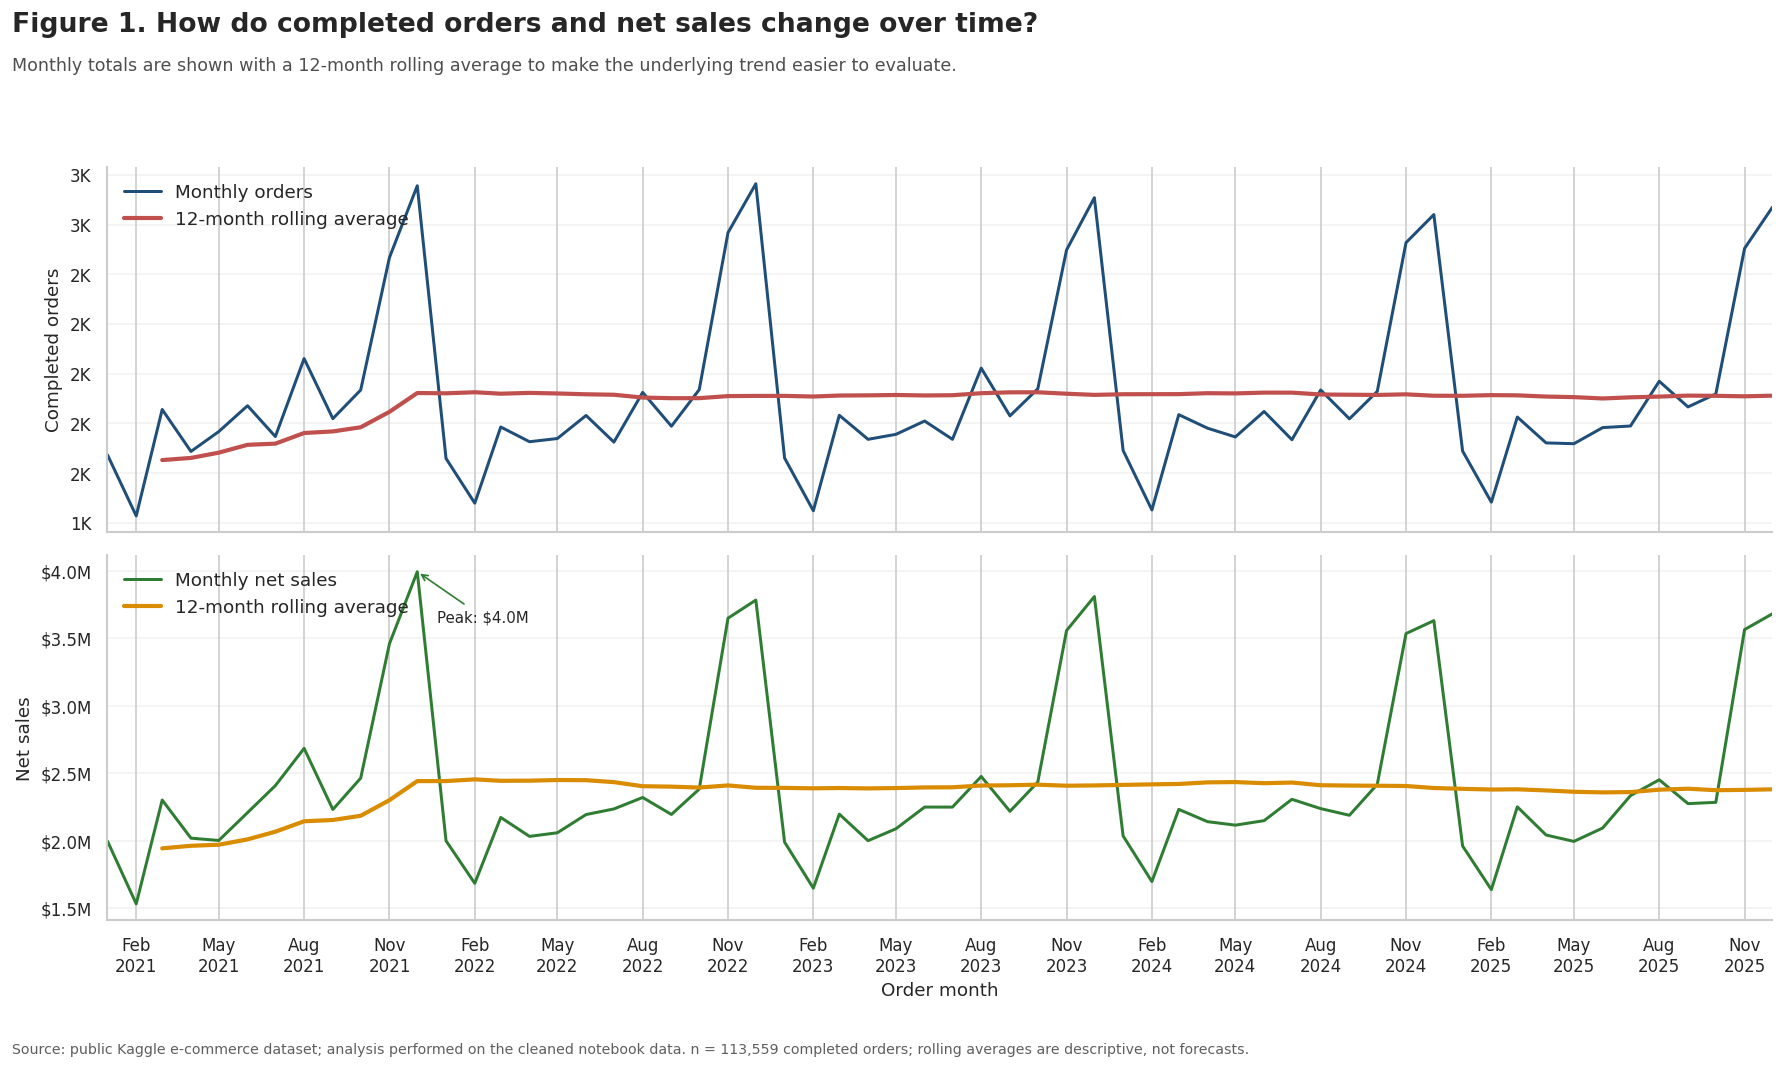

In [ ]:
# FIGURE 1 — MONTHLY ORDERS AND NET SALES
monthly_plot = monthly_summary.sort_values("order_month_period").copy()
monthly_plot["Orders_12M_MA"] = monthly_plot["Orders"].rolling(12, min_periods=3).mean()
monthly_plot["Net_Sales_12M_MA"] = monthly_plot["Net_Sales"].rolling(12, min_periods=3).mean()
monthly_dates = monthly_plot["order_month_period"].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
fig.suptitle(
    "Figure 1. How do completed orders and net sales change over time?",
    x=0.01,
    ha="left",
    fontsize=16,
    fontweight="bold",
)
fig.text(
    0.01,
    0.925,
    "Monthly totals are shown with a 12-month rolling average to make the underlying trend easier to evaluate.",
    fontsize=10.5,
    color="#4f4f4f",
)

axes[0].plot(monthly_dates, monthly_plot["Orders"], color=COLORS["primary"], linewidth=1.8, label="Monthly orders")
axes[0].plot(monthly_dates, monthly_plot["Orders_12M_MA"], color=COLORS["accent"], linewidth=2.5, label="12-month rolling average")
axes[0].set_ylabel("Completed orders")
axes[0].legend(loc="upper left")
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x / 1000:.0f}K"))
axes[0].grid(axis="y", alpha=0.25)

axes[1].plot(monthly_dates, monthly_plot["Net_Sales"], color=COLORS["positive"], linewidth=1.8, label="Monthly net sales")
axes[1].plot(monthly_dates, monthly_plot["Net_Sales_12M_MA"], color=COLORS["highlight"], linewidth=2.5, label="12-month rolling average")
axes[1].set_ylabel("Net sales")
axes[1].set_xlabel("Order month")
axes[1].legend(loc="upper left")
axes[1].yaxis.set_major_formatter(FuncFormatter(money_fmt))
axes[1].grid(axis="y", alpha=0.25)


for ax in axes:
    sns.despine(ax=ax)

axes[1].xaxis.set_major_locator(
    mdates.MonthLocator(interval=3)
)

axes[1].xaxis.set_major_formatter(
    mdates.DateFormatter("%b\n%Y")
)

axes[1].set_xlim(
    monthly_dates.min(),
    monthly_dates.max()
)
# Identify the month with the highest net sales
peak_sales = monthly_plot.loc[
    monthly_plot["Net_Sales"].idxmax()
]

axes[1].annotate(
    f"Peak: {money_fmt(peak_sales['Net_Sales'], 0)}",
    xy=(
        peak_sales["order_month_period"].to_timestamp(),
        peak_sales["Net_Sales"]
    ),
    xytext=(12, -30),
    textcoords="offset points",
    arrowprops={
        "arrowstyle": "->",
        "color": COLORS["positive"]
    },
    fontsize=9,
    ha="left"
)

add_source_note(fig, f"n = {len(completed):,} completed orders; rolling averages are descriptive, not forecasts.")
fig.tight_layout(rect=[0, 0.045, 1, 0.90])
fig.savefig(FIG_DIR / "fig_01_monthly_orders_sales.png", dpi=300, bbox_inches="tight")
plt.show()

labels are being reduced to every quarterly months to prevent crowding.

EDA Question 2 — What share of all orders reaches each order status?

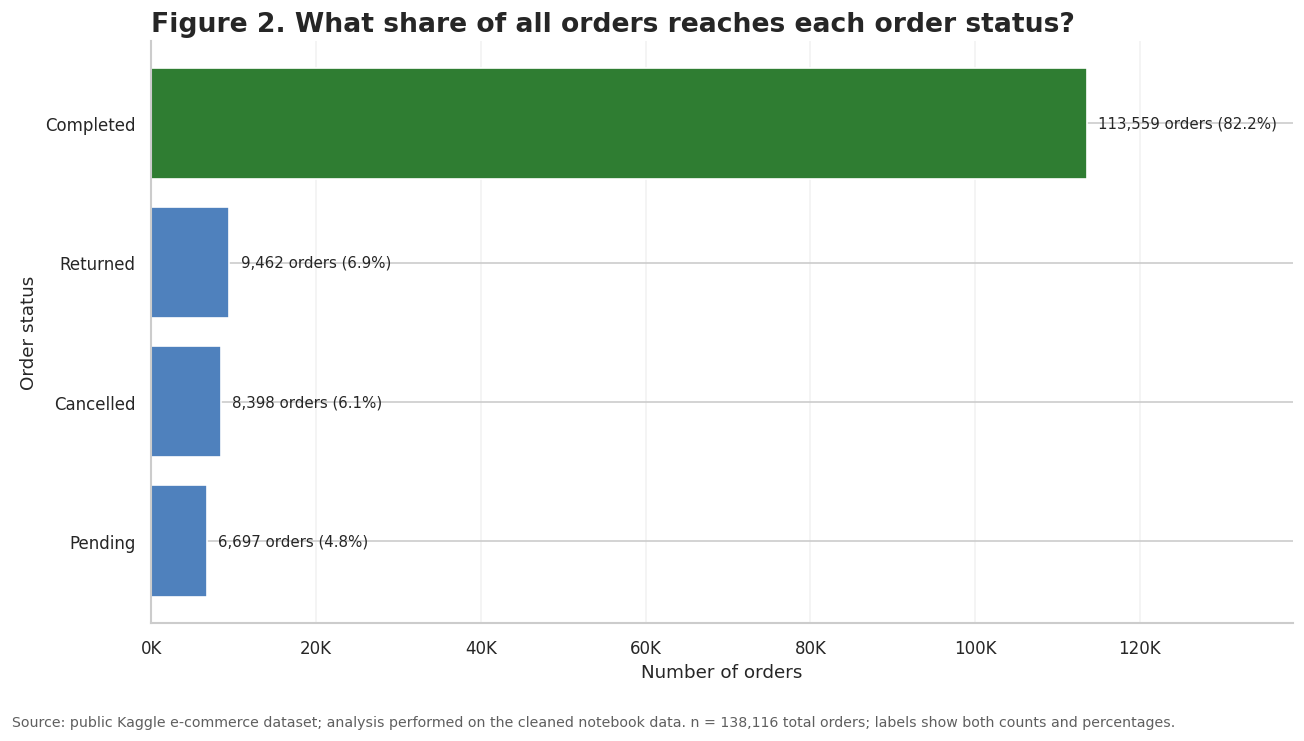

In [ ]:
# FIGURE 2 — ORDER STATUS DISTRIBUTION
status_plot = (
    df_clean["order_status"]
    .value_counts()
    .rename_axis("Order Status")
    .reset_index(name="Orders")
)
status_plot["Share"] = status_plot["Orders"] / status_plot["Orders"].sum() * 100
status_plot = status_plot.sort_values("Orders")

status_colors = [
    COLORS["positive"] if status == "Completed" else COLORS["secondary"]
    for status in status_plot["Order Status"]
]

fig, ax = plt.subplots(figsize=(11, 6.5))
bars = ax.barh(status_plot["Order Status"], status_plot["Orders"], color=status_colors)
labels = [f"{n:,.0f} orders ({p:.1f}%)" for n, p in zip(status_plot["Orders"], status_plot["Share"])]
annotate_bar_values(ax, bars, status_plot["Orders"], labels, horizontal=True)
ax.set_title("Figure 2. What share of all orders reaches each order status?", loc="left", fontsize=16, fontweight="bold")
ax.set_xlabel("Number of orders")
ax.set_ylabel("Order status")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x / 1000:.0f}K"))
ax.set_xlim(0, status_plot["Orders"].max() * 1.22)
ax.grid(axis="x", alpha=0.25)
sns.despine(ax=ax)
add_source_note(fig, f"n = {len(df_clean):,} total orders; labels show both counts and percentages.")
fig.tight_layout(rect=[0, 0.045, 1, 0.96])
fig.savefig(FIG_DIR / "fig_02_order_status.png", dpi=300, bbox_inches="tight")
plt.show()

Question 3 — Which sales channels contribute the most net sales and profit?

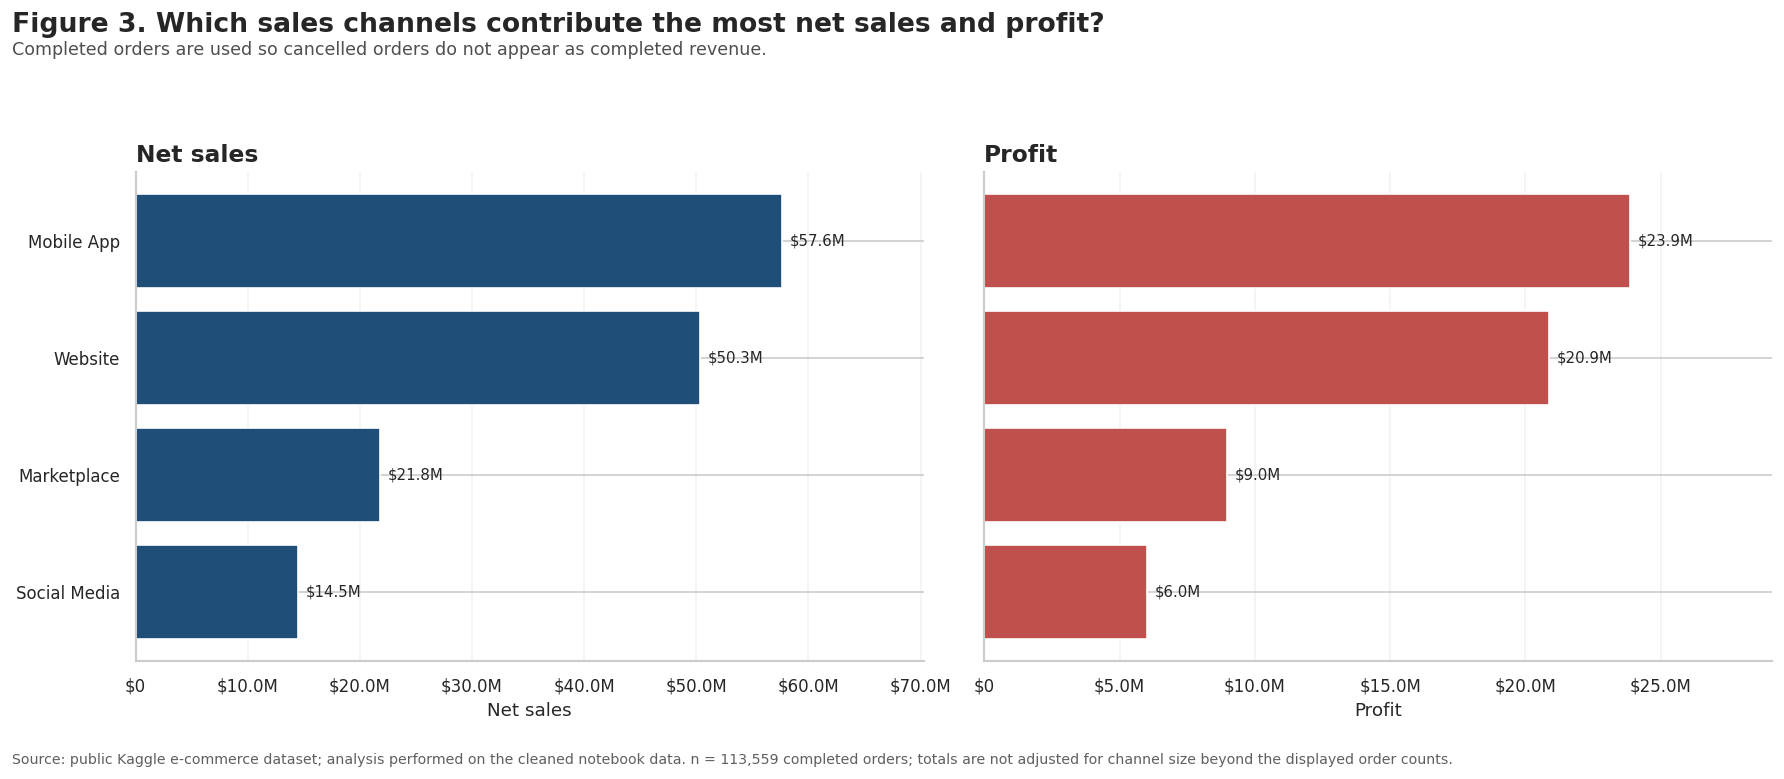

In [ ]:
# FIGURE 3 — CHANNEL SALES AND PROFIT
channel_plot = channel_summary.sort_values("Net_Sales").copy()
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), sharey=True)
fig.suptitle(
    "Figure 3. Which sales channels contribute the most net sales and profit?",
    x=0.01,
    ha="left",
    fontsize=16,
    fontweight="bold",
)
fig.text(0.01, 0.925, "Completed orders are used so cancelled orders do not appear as completed revenue.", fontsize=10.5, color="#4f4f4f")

sales_bars = axes[0].barh(channel_plot["sales_channel"], channel_plot["Net_Sales"], color=COLORS["primary"])
sales_labels = [money_fmt(v, 0) for v in channel_plot["Net_Sales"]]
annotate_bar_values(axes[0], sales_bars, channel_plot["Net_Sales"], sales_labels, horizontal=True)
axes[0].set_title("Net sales", loc="left", fontweight="bold")
axes[0].set_xlabel("Net sales")
axes[0].xaxis.set_major_formatter(FuncFormatter(money_fmt))

profit_bars = axes[1].barh(channel_plot["sales_channel"], channel_plot["Profit"], color=COLORS["accent"])
profit_labels = [money_fmt(v, 0) for v in channel_plot["Profit"]]
annotate_bar_values(axes[1], profit_bars, channel_plot["Profit"], profit_labels, horizontal=True)
axes[1].set_title("Profit", loc="left", fontweight="bold")
axes[1].set_xlabel("Profit")
axes[1].xaxis.set_major_formatter(FuncFormatter(money_fmt))

for ax in axes:
    ax.grid(axis="x", alpha=0.25)
    sns.despine(ax=ax)

axes[0].set_xlim(0, channel_plot["Net_Sales"].max() * 1.22)
axes[1].set_xlim(0, channel_plot["Profit"].max() * 1.22)
add_source_note(fig, f"n = {len(completed):,} completed orders; totals are not adjusted for channel size beyond the displayed order counts.")
fig.tight_layout(rect=[0, 0.045, 1, 0.90])
fig.savefig(FIG_DIR / "fig_03_channel_sales_profit.png", dpi=300, bbox_inches="tight")
plt.show()

Question 4 — Which customer segments contribute the most sales and average order value?

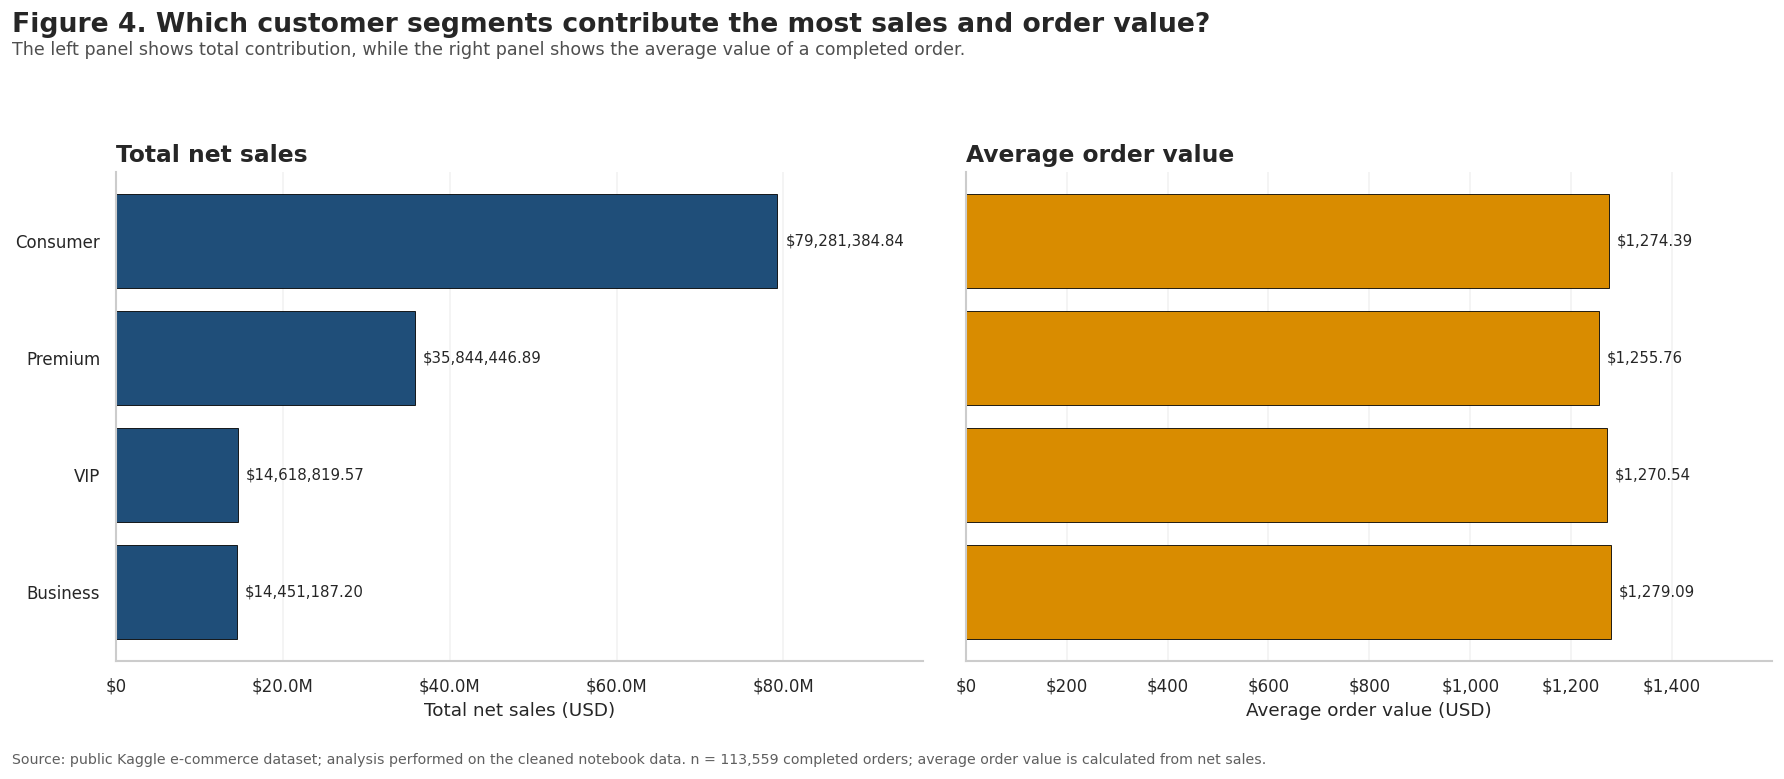

In [ ]:
# FIGURE 4 — CUSTOMER SEGMENT PERFORMANCE

segment_plot = (
    segment_summary
    .sort_values("Net_Sales")
    .copy()
)

# Using a precise formatter for average order value.
def average_order_fmt(value, position):
    return f"${value:,.0f}"

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6.5),
    sharey=True
)

fig.suptitle(
    "Figure 4. Which customer segments contribute the most sales and order value?",
    x=0.01,
    ha="left",
    fontsize=16,
    fontweight="bold"
)

fig.text(
    0.01,
    0.925,
    "The left panel shows total contribution, while the right panel shows the average value of a completed order.",
    fontsize=10.5,
    color="#4f4f4f"
)

# Left panel: total net sales
sales_bars = axes[0].barh(
    segment_plot["customer_segment"],
    segment_plot["Net_Sales"],
    color=COLORS["primary"],
    edgecolor="black",
    linewidth=0.5
)

sales_labels = [
    f"${value:,.2f}"
    for value in segment_plot["Net_Sales"]
]

annotate_bar_values(
    axes[0],
    sales_bars,
    segment_plot["Net_Sales"],
    sales_labels,
    horizontal=True
)

axes[0].set_title(
    "Total net sales",
    loc="left",
    fontweight="bold"
)

axes[0].set_xlabel(
    "Total net sales (USD)"
)

axes[0].xaxis.set_major_formatter(
    FuncFormatter(money_fmt)
)

# Right panel: average order value
order_bars = axes[1].barh(
    segment_plot["customer_segment"],
    segment_plot["Average_Order_Value"],
    color=COLORS["highlight"],
    edgecolor="black",
    linewidth=0.5
)

order_labels = [
    f"${value:,.2f}"
    for value in segment_plot["Average_Order_Value"]
]

annotate_bar_values(
    axes[1],
    order_bars,
    segment_plot["Average_Order_Value"],
    order_labels,
    horizontal=True
)

axes[1].set_title(
    "Average order value",
    loc="left",
    fontweight="bold"
)

axes[1].set_xlabel(
    "Average order value (USD)"
)

axes[1].xaxis.set_major_formatter(
    FuncFormatter(average_order_fmt)
)

# Improve both panels
for ax in axes:
    ax.grid(
        axis="x",
        alpha=0.25
    )

    # Remove horizontal gridlines behind the bars
    ax.grid(
        axis="y",
        visible=False
    )

    sns.despine(ax=ax)

# Add space for annotations
axes[0].set_xlim(
    0,
    segment_plot["Net_Sales"].max() * 1.22
)

axes[1].set_xlim(
    0,
    segment_plot["Average_Order_Value"].max() * 1.25
)

add_source_note(
    fig,
    f"n = {len(completed):,} completed orders; average order value is calculated from net sales."
)

fig.tight_layout(
    rect=[0, 0.045, 1, 0.90]
)

fig.savefig(
    FIG_DIR / "fig_04_segment_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Question 5 — How common are delayed deliveries among completed orders?

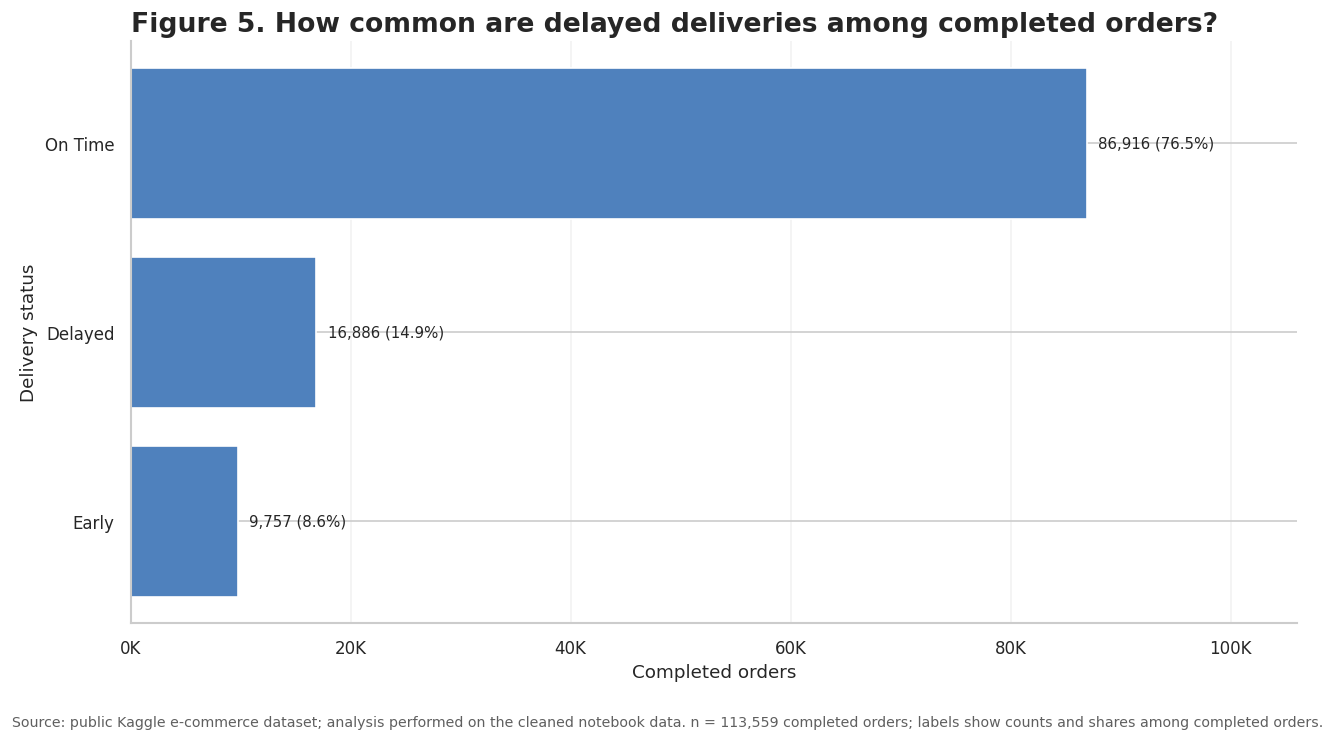

In [ ]:
# FIGURE 5 — DELIVERY STATUS DISTRIBUTION
delivery_plot = (
    completed["delivery_status"]
    .value_counts()
    .rename_axis("Delivery Status")
    .reset_index(name="Orders")
)
delivery_plot["Share"] = delivery_plot["Orders"] / delivery_plot["Orders"].sum() * 100
delivery_plot = delivery_plot.sort_values("Orders")

fig, ax = plt.subplots(figsize=(11, 6.5))
bars = ax.barh(delivery_plot["Delivery Status"], delivery_plot["Orders"], color=COLORS["secondary"])
labels = [f"{n:,.0f} ({p:.1f}%)" for n, p in zip(delivery_plot["Orders"], delivery_plot["Share"])]
annotate_bar_values(ax, bars, delivery_plot["Orders"], labels, horizontal=True)
ax.set_title("Figure 5. How common are delayed deliveries among completed orders?", loc="left", fontsize=16, fontweight="bold")
ax.set_xlabel("Completed orders")
ax.set_ylabel("Delivery status")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x / 1000:.0f}K"))
ax.set_xlim(0, delivery_plot["Orders"].max() * 1.22)
ax.grid(axis="x", alpha=0.25)
sns.despine(ax=ax)
add_source_note(fig, f"n = {len(completed):,} completed orders; labels show counts and shares among completed orders.")
fig.tight_layout(rect=[0, 0.045, 1, 0.96])
fig.savefig(FIG_DIR / "fig_05_delivery_status.png", dpi=300, bbox_inches="tight")
plt.show()

Question 6 — Are customer ratings different across delivery-status groups?

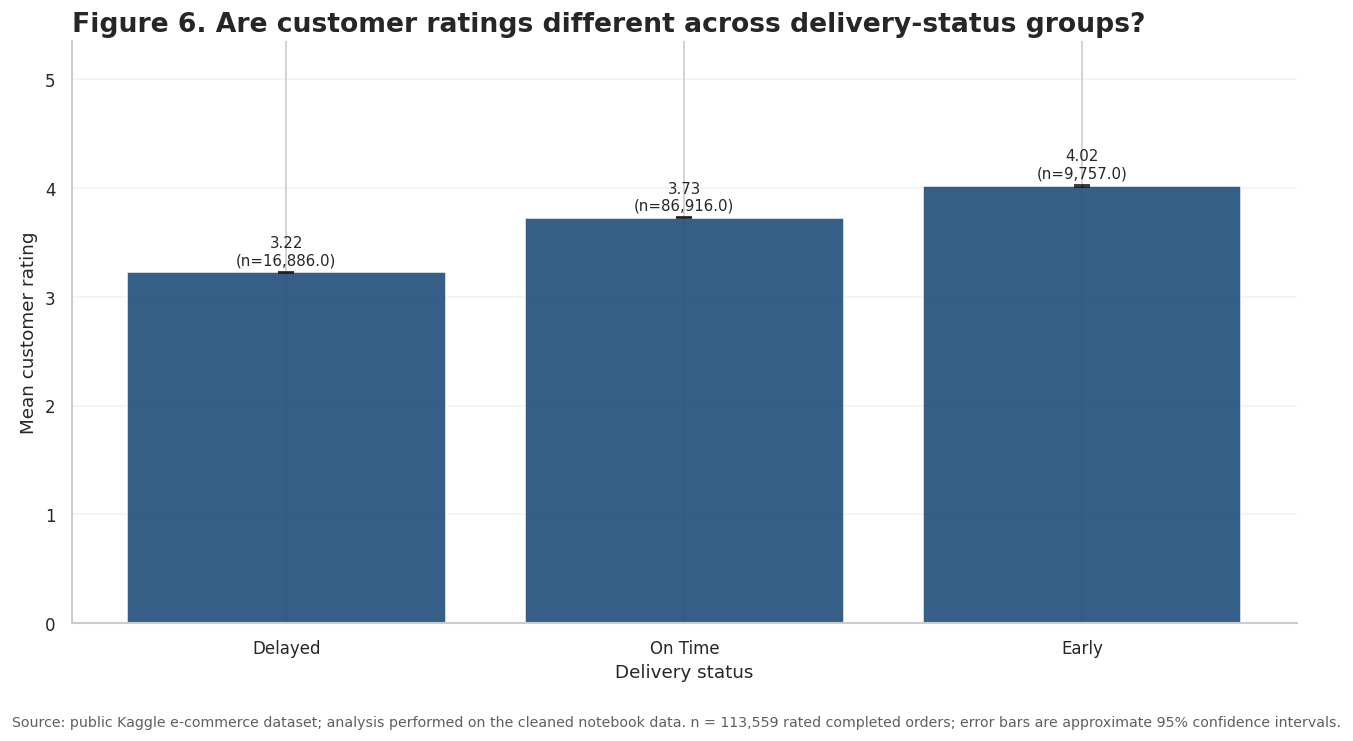

In [ ]:
# FIGURE 6 — RATING BY DELIVERY STATUS WITH 95% CONFIDENCE INTERVALS
rating_data = completed.dropna(subset=["delivery_status", "customer_rating"])
rating_stats = (
    rating_data.groupby("delivery_status")
    .agg(
        Average_Rating=("customer_rating", "mean"),
        Standard_Deviation=("customer_rating", "std"),
        N=("customer_rating", "count"),
    )
    .sort_values("Average_Rating")
)
rating_stats["CI95"] = (
    1.96
    * rating_stats["Standard_Deviation"].fillna(0)
    / np.sqrt(rating_stats["N"])
)

fig, ax = plt.subplots(figsize=(11, 6.5))
bars = ax.bar(
    rating_stats.index,
    rating_stats["Average_Rating"],
    yerr=rating_stats["CI95"],
    capsize=5,
    color=COLORS["primary"],
    alpha=0.9,
)
for bar, (_, row) in zip(bars, rating_stats.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + row["CI95"] + 0.04,
        f"{row['Average_Rating']:.2f}\n(n={row['N']:,})",
        ha="center",
        va="bottom",
        fontsize=9,
    )
ax.set_title("Figure 6. Are customer ratings different across delivery-status groups?", loc="left", fontsize=16, fontweight="bold")
ax.set_xlabel("Delivery status")
ax.set_ylabel("Mean customer rating")
ax.set_ylim(0, 5.35)
ax.grid(axis="y", alpha=0.25)
sns.despine(ax=ax)
add_source_note(fig, f"n = {len(rating_data):,} rated completed orders; error bars are approximate 95% confidence intervals.")
fig.tight_layout(rect=[0, 0.045, 1, 0.96])
fig.savefig(FIG_DIR / "fig_06_rating_delivery_status.png", dpi=300, bbox_inches="tight")
plt.show()

Question 7 — Which customer segment has the highest repeat-customer rate?

,customer_segment,Repeat_Rate,N,Repeat_Customers,Repeat_Percent,CI95
3,VIP,0.98,2536,2481,97.83,0.57
0,Business,0.98,2515,2461,97.85,0.57
2,Premium,0.98,6275,6143,97.90,0.36
1,Consumer,0.98,13585,13302,97.92,0.24


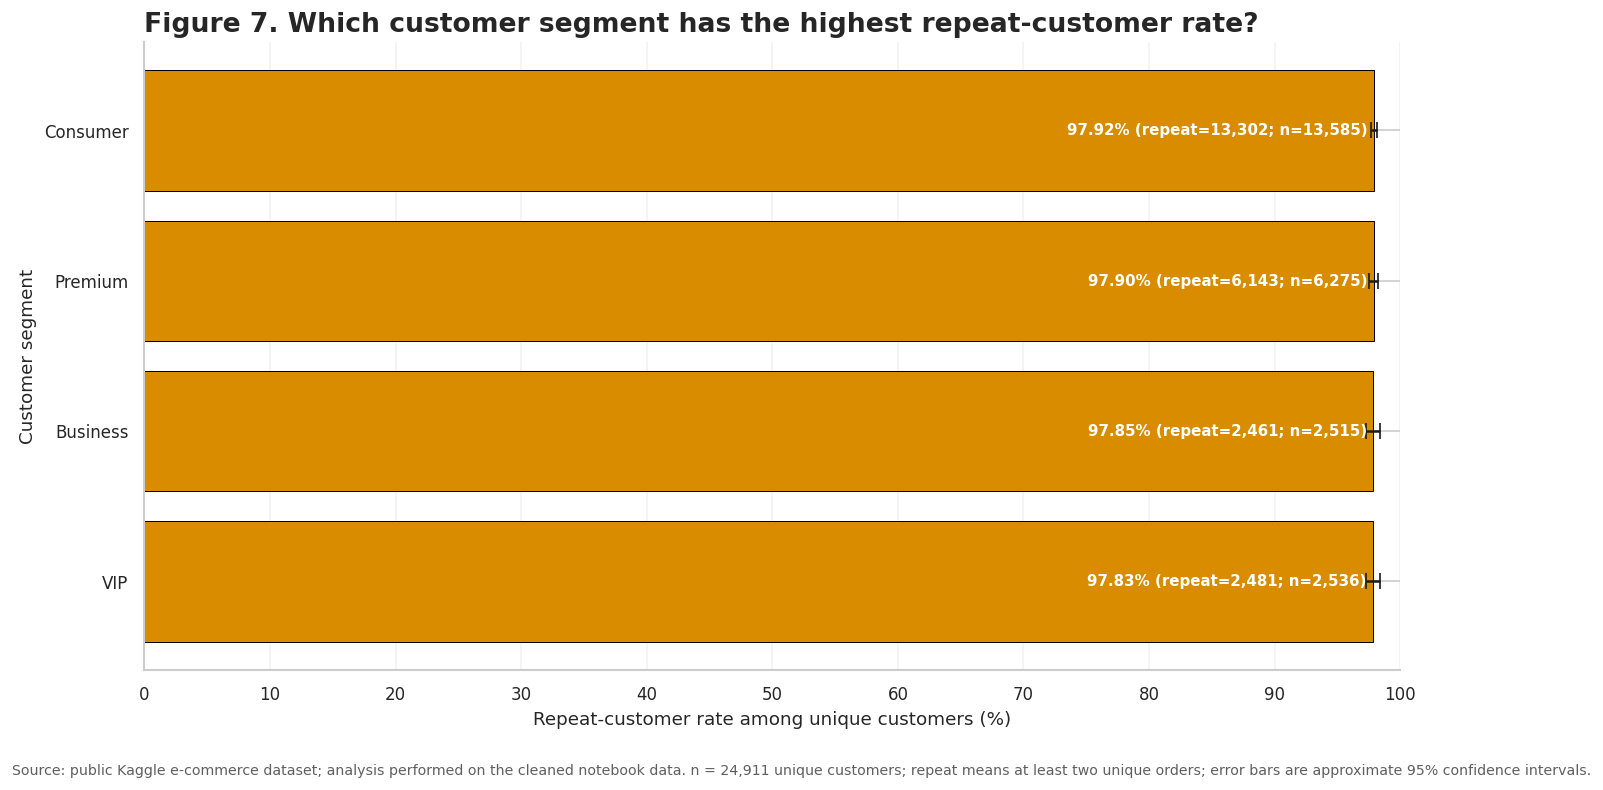

In [ ]:
# FIGURE 7 — REPEAT-CUSTOMER RATE BY SEGMENT WITH 95% CONFIDENCE INTERVALS
# FIGURE 7 — CUSTOMER-LEVEL REPEAT RATE BY SEGMENT
# Repeat status is recalculated from each customer's actual order history.
# This prevents customers with many orders from being counted multiple times.

# Count the number of unique orders for each customer
customer_order_counts = (
    df_clean.groupby("customer_id", as_index=False)
    .agg(
        Order_Count=("order_id", "nunique")
    )
)

# Keep one customer segment per customer.
# The first observed segment is used for the customer-level analysis.
customer_segments = (
    df_clean.sort_values("order_datetime")
    .drop_duplicates("customer_id")
    [["customer_id", "customer_segment"]]
)

# Combine customer segment and order count
customer_level = customer_segments.merge(
    customer_order_counts,
    on="customer_id",
    how="left"
)

# A customer with two or more orders is classified as a repeat customer
customer_level["Repeat_Flag"] = (
    customer_level["Order_Count"] >= 2
).astype(int)

# Calculate repeat rate for each customer segment
repeat_stats = (
    customer_level.groupby("customer_segment", as_index=False)
    .agg(
        Repeat_Rate=("Repeat_Flag", "mean"),
        N=("customer_id", "nunique"),
        Repeat_Customers=("Repeat_Flag", "sum")
    )
)

# Convert the repeat rate to a percentage
repeat_stats["Repeat_Percent"] = (
    repeat_stats["Repeat_Rate"] * 100
)

# Calculate approximate 95% binomial confidence intervals
repeat_stats["CI95"] = (
    1.96
    * np.sqrt(
        repeat_stats["Repeat_Rate"]
        * (1 - repeat_stats["Repeat_Rate"])
        / repeat_stats["N"]
    )
    * 100
)

# Sort segments from lowest to highest repeat rate
repeat_stats = repeat_stats.sort_values(
    "Repeat_Percent"
)

# Display the corrected statistics before plotting
display(repeat_stats)

# Create the research-style figure
fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    repeat_stats["customer_segment"],
    repeat_stats["Repeat_Percent"],
    xerr=repeat_stats["CI95"],
    capsize=5,
    color=COLORS["highlight"],
    edgecolor="black",
    linewidth=0.6
)

# Add readable labels to each bar
for bar, (_, row) in zip(
    bars,
    repeat_stats.iterrows()
):
    repeat_percent = float(row["Repeat_Percent"])
    confidence_interval = float(row["CI95"])
    customer_count = int(row["N"])
    repeat_count = int(row["Repeat_Customers"])

    label = (
        f"{repeat_percent:.2f}% "
        f"(repeat={repeat_count:,}; n={customer_count:,})"
    )

    # Put labels inside bars when the rate is close to 100%
    if repeat_percent >= 85:
        ax.text(
            repeat_percent - 0.5,
            bar.get_y() + bar.get_height() / 2,
            label,
            va="center",
            ha="right",
            color="white",
            fontsize=9,
            fontweight="bold"
        )
    else:
        ax.text(
            repeat_percent + confidence_interval + 0.5,
            bar.get_y() + bar.get_height() / 2,
            label,
            va="center",
            ha="left",
            fontsize=9
        )

ax.set_title(
    "Figure 7. Which customer segment has the highest repeat-customer rate?",
    loc="left",
    fontsize=16,
    fontweight="bold"
)
ax.set_xlabel(
    "Repeat-customer rate among unique customers (%)"
)

ax.set_ylabel(
    "Customer segment"
)

ax.set_xlim(0, 100)

ax.set_xticks(range(0, 101, 10))

ax.grid(
    axis="x",
    alpha=0.25
)

sns.despine(ax=ax)

add_source_note(
    fig,
    f"n = {len(customer_level):,} unique customers; repeat means at least two unique orders; error bars are approximate 95% confidence intervals."
)

fig.tight_layout(
    rect=[0, 0.045, 1, 0.95]
)

fig.savefig(
    FIG_DIR / "fig_07_repeat_customer_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Question 8 — When do customers place orders, and does weekend activity differ?

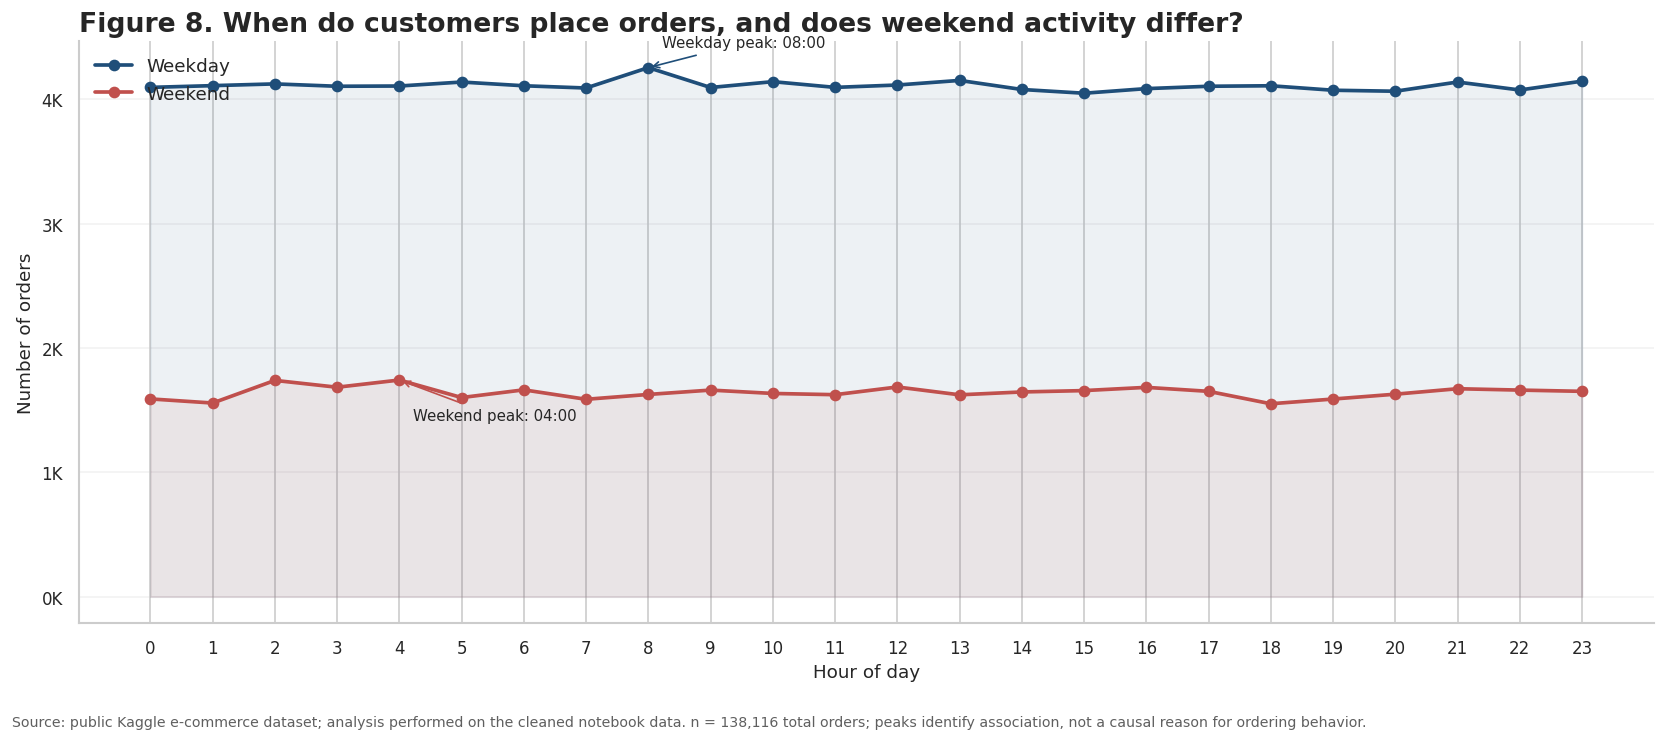

In [ ]:
# FIGURE 8 — ORDER ACTIVITY BY HOUR AND WEEKEND STATUS
hourly = (
    df_clean.groupby(["order_hour", "is_weekend"])
    .size()
    .unstack(fill_value=0)
    .reindex(range(24), fill_value=0)
)
weekday_counts = hourly[False] if False in hourly.columns else pd.Series(0, index=hourly.index)
weekend_counts = hourly[True] if True in hourly.columns else pd.Series(0, index=hourly.index)

fig, ax = plt.subplots(figsize=(14, 6.5))
ax.plot(hourly.index, weekday_counts, marker="o", linewidth=2.2, color=COLORS["primary"], label="Weekday")
ax.plot(hourly.index, weekend_counts, marker="o", linewidth=2.2, color=COLORS["accent"], label="Weekend")
ax.fill_between(hourly.index, weekday_counts, alpha=0.08, color=COLORS["primary"])
ax.fill_between(hourly.index, weekend_counts, alpha=0.08, color=COLORS["accent"])

weekday_peak_hour = weekday_counts.idxmax()
weekend_peak_hour = weekend_counts.idxmax()
ax.annotate(
    f"Weekday peak: {weekday_peak_hour:02d}:00",
    xy=(weekday_peak_hour, weekday_counts.loc[weekday_peak_hour]),
    xytext=(8, 12),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": COLORS["primary"]},
    fontsize=9,
)
ax.annotate(
    f"Weekend peak: {weekend_peak_hour:02d}:00",
    xy=(weekend_peak_hour, weekend_counts.loc[weekend_peak_hour]),
    xytext=(8, -24),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": COLORS["accent"]},
    fontsize=9,
)

ax.set_title("Figure 8. When do customers place orders, and does weekend activity differ?", loc="left", fontsize=16, fontweight="bold")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Number of orders")
ax.set_xticks(range(24))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x / 1000:.0f}K"))
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.25)
sns.despine(ax=ax)
add_source_note(fig, f"n = {len(df_clean):,} total orders; peaks identify association, not a causal reason for ordering behavior.")
fig.tight_layout(rect=[0, 0.045, 1, 0.96])
fig.savefig(FIG_DIR / "fig_08_order_activity_by_hour.png", dpi=300, bbox_inches="tight")
plt.show()